# 02 — Rain Gauge Processing

Processes raw precipitation data from three stations:
- **Gazelle Valley** and **Ziv** — LAB tipping-bucket gauges (0.1 mm tip resolution)
- **Givat Ram** — IMS official gauge (pre-aggregated 10-min)

For each station the notebook:
1. Resamples to a fixed interval and computes rain depth per step.
2. Zeroes out July–August for LAB gauges (dew artefact).
3. Computes rolling rainfall intensities (mm/hr) for multiple durations.
4. Saves cleaned `_processed.csv` files.
5. Identifies discrete rain events from the Givat Ram series.

**Outputs:** `*_processed.csv` per station, `rain_events_givat_ram.csv`

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import config as cfg
from utils.rain import process_lab_gauge, process_ims_gauge, identify_rain_events
from utils.plots import plot_rain_intensity, plot_cumulative_rain

## 1  Process gauges

In [2]:
gv_rain  = process_lab_gauge(cfg.GV_RAW_CSV,  interval_min=10, durations_min=cfg.INTENSITY_DURATIONS)
ziv_rain = process_lab_gauge(cfg.ZIV_RAW_CSV, interval_min=10, durations_min=cfg.INTENSITY_DURATIONS)
ram_rain = process_ims_gauge(cfg.RAM_RAW_CSV,                  durations_min=cfg.INTENSITY_DURATIONS)

print(f"Gazelle Valley : {len(gv_rain):,} rows")
print(f"Ziv            : {len(ziv_rain):,} rows")
print(f"Givat Ram      : {len(ram_rain):,} rows")

IMS gauge — detected interval: 10min  (step breakdown: [(600.0, 130043), (1200.0, 17), (1800.0, 7)])
Gazelle Valley : 104,588 rows
Ziv            : 104,717 rows
Givat Ram      : 130,117 rows


## 2  Save processed files

In [3]:
gv_rain.to_csv(cfg.GV_PROC_CSV,  index=False)
ziv_rain.to_csv(cfg.ZIV_PROC_CSV, index=False)
ram_rain.to_csv(cfg.RAM_PROC_CSV, index=False)
print('Saved processed rain files.')

Saved processed rain files.


## 3  Identify rain events (Givat Ram)

In [4]:
rain_events = identify_rain_events(
    ram_rain,
    min_dry_gap_hours=cfg.MIN_DRY_GAP_HOURS,
    min_event_total_mm=cfg.MIN_EVENT_TOTAL_MM,
)
rain_events.to_csv(cfg.RAIN_EVENTS_RAM_CSV, index=False)
print(f"Identified {len(rain_events)} rain events → {cfg.RAIN_EVENTS_RAM_CSV}")
rain_events.head(10)

Identified 99 rain events → D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\rain_events_givat_ram.csv


,rain_event_start,rain_event_end,total_rain_mm
0,2023-11-01 11:50:00,2023-11-01 15:40:00,7.8
1,2023-11-14 14:40:00,2023-11-14 21:20:00,2.9
2,2023-11-19 14:10:00,2023-11-20 22:30:00,57.1
3,2023-11-27 03:20:00,2023-11-27 18:20:00,19.8
4,2023-12-05 15:40:00,2023-12-05 21:40:00,9.1
5,2023-12-06 11:30:00,2023-12-06 12:20:00,2.1
6,2023-12-09 00:20:00,2023-12-09 00:40:00,1.3
7,2023-12-12 16:30:00,2023-12-13 15:00:00,10.3
8,2023-12-23 15:40:00,2023-12-24 16:10:00,30.6
9,2024-01-02 07:40:00,2024-01-02 09:30:00,0.7


## 4  Dew check — summer rain by hour of day

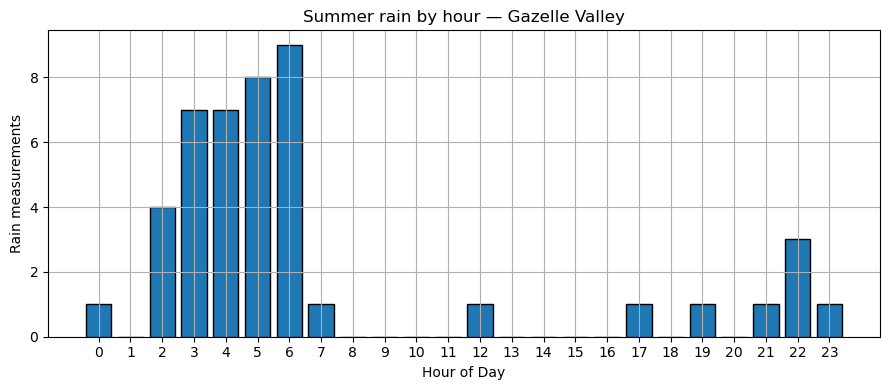

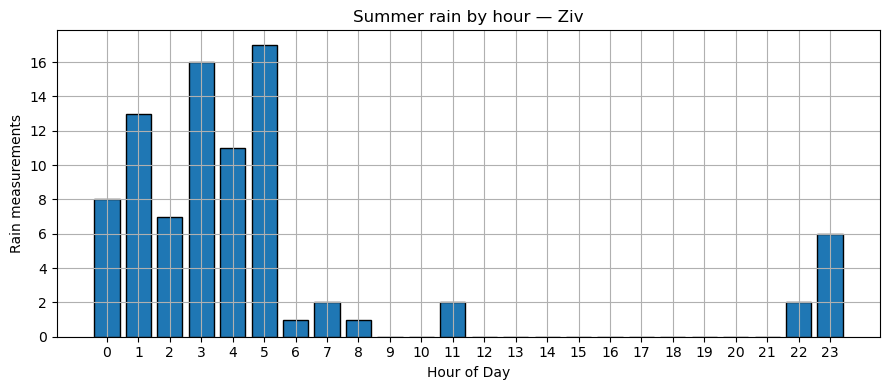

In [5]:
def plot_summer_hour_hist(df, station_name):
    summer = df[df['date_time'].dt.month.isin([6, 7, 8, 9])]
    summer = summer[summer['rain_mm'] > 0].copy()
    summer['hour'] = summer['date_time'].dt.hour
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(summer['hour'], bins=range(25), edgecolor='black', align='left', rwidth=0.8)
    ax.set_xticks(range(24))
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Rain measurements')
    ax.set_title(f'Summer rain by hour — {station_name}')
    ax.grid(True)
    fig.tight_layout()
    plt.show()

plot_summer_hour_hist(gv_rain,  'Gazelle Valley')
plot_summer_hour_hist(ziv_rain, 'Ziv')

## 5  Rain intensity plots

C:\Users\raznu\AppData\Local\Temp\ipykernel_117284\84043383.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plot_rain_intensity(rain_dfs, labels, '21/09/2023 00:30', '10/11/2024 00:00').show()


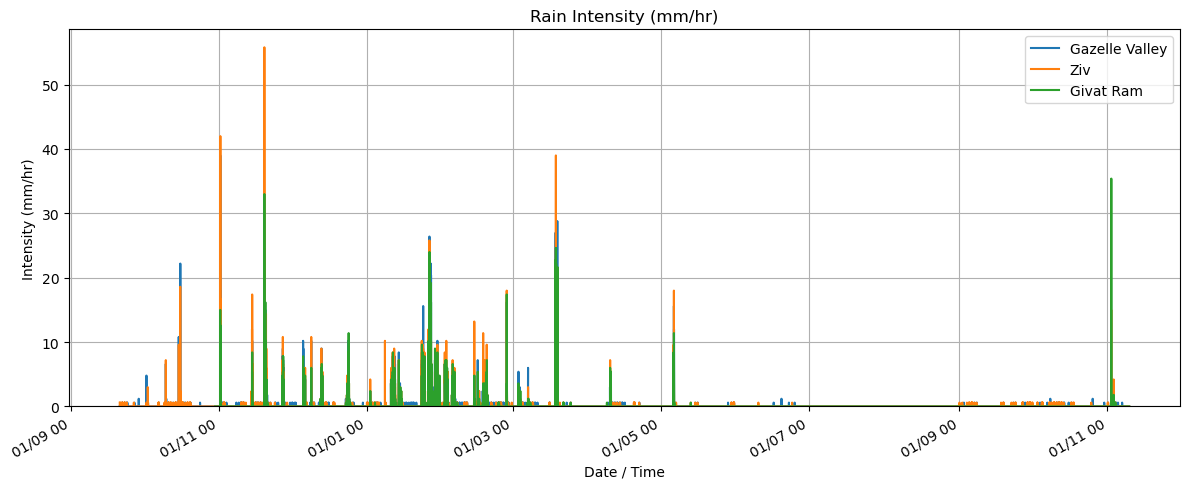

In [6]:
rain_dfs = [gv_rain, ziv_rain, ram_rain]
labels   = ['Gazelle Valley', 'Ziv', 'Givat Ram']

plot_rain_intensity(rain_dfs, labels, '21/09/2023 00:30', '10/11/2024 00:00').show()

## 6  Cumulative rain by season

Season 2023/2024
Gazelle Valley: 506.5 mm
Ziv: 552.1 mm
Givat Ram: 462.1 mm
Season 2024/2025
Gazelle Valley: 257.1 mm
Ziv: 300.6 mm
Givat Ram: 256.9 mm


C:\Users\raznu\AppData\Local\Temp\ipykernel_117284\2519141081.py:2: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plot_cumulative_rain(rain_dfs, labels, '21/09/2023 00:30', '01/09/2024 00:00').show()
C:\Users\raznu\AppData\Local\Temp\ipykernel_117284\2519141081.py:5: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plot_cumulative_rain(rain_dfs, labels, '01/09/2024 00:30', '01/09/2025 00:00').show()
C:\Users\raznu\AppData\Local\Temp\ipykernel_117284\2519141081.py:8: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plot_cumulative_rain([ram_rain], ['Givat Ram'], '01/09/2025 00:30', '21/01/2026 00:00').show()


Season 2025/2026 (ongoing)
Givat Ram: 402.3 mm


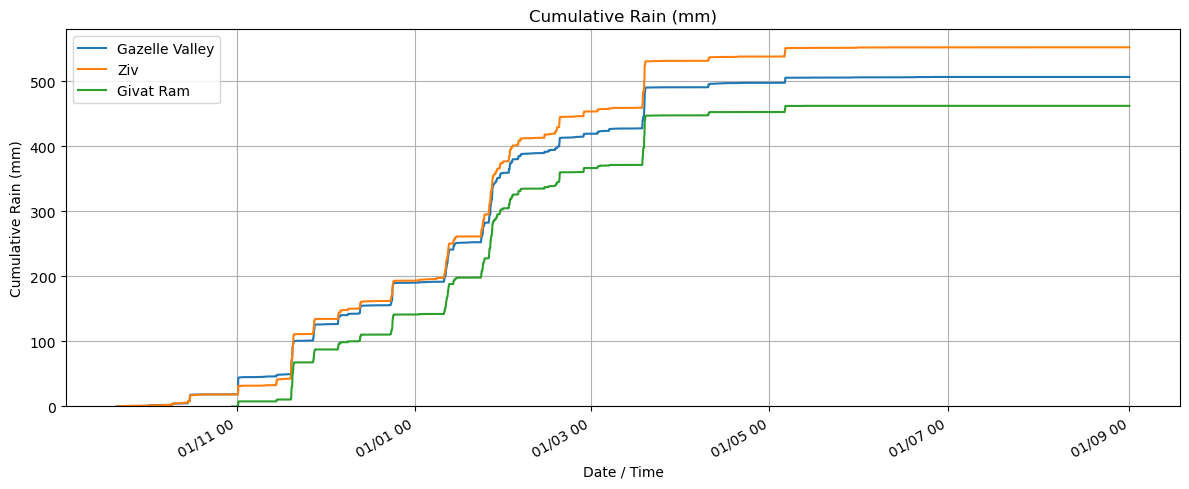

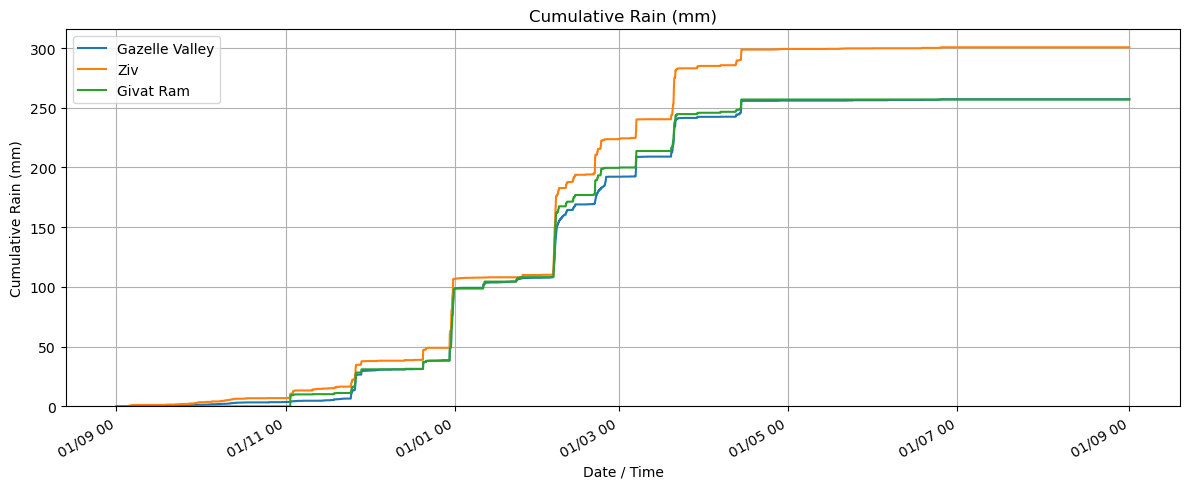

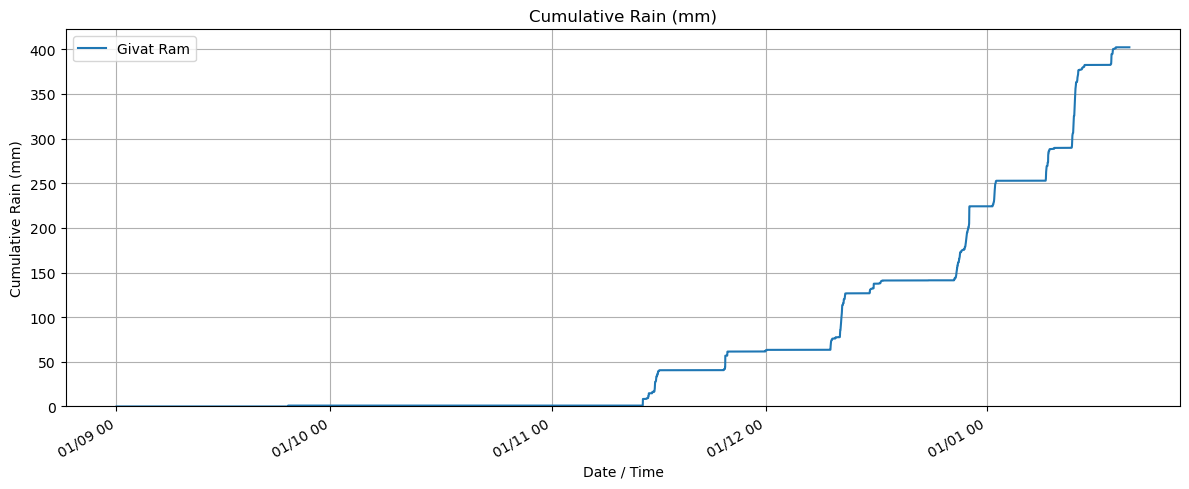

In [7]:
print('Season 2023/2024')
plot_cumulative_rain(rain_dfs, labels, '21/09/2023 00:30', '01/09/2024 00:00').show()

print('Season 2024/2025')
plot_cumulative_rain(rain_dfs, labels, '01/09/2024 00:30', '01/09/2025 00:00').show()

print('Season 2025/2026 (ongoing)')
plot_cumulative_rain([ram_rain], ['Givat Ram'], '01/09/2025 00:30', '21/01/2026 00:00').show()

## 7  Annual cumulative rainfall (Givat Ram)

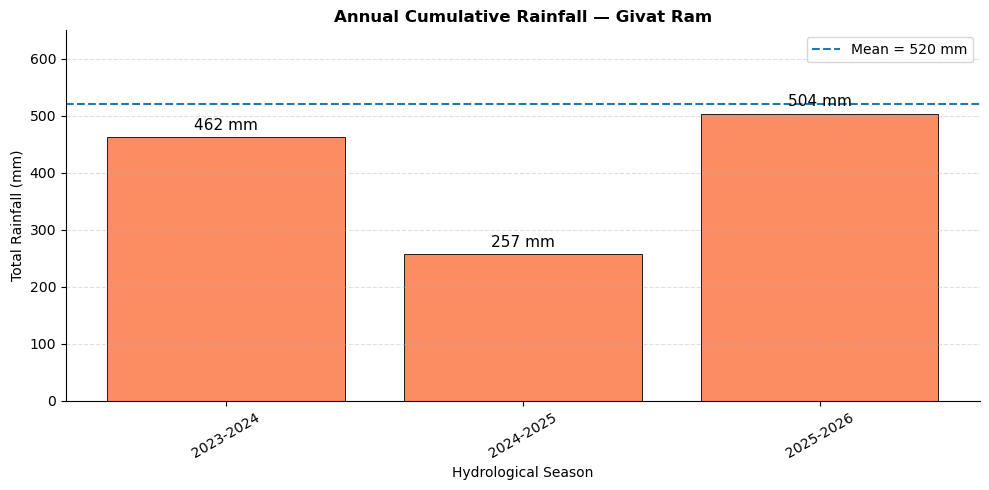

In [8]:
def get_hydro_season(d):
    yr = d.year
    return f"{yr}-{yr+1}" if d.month >= 9 else f"{yr-1}-{yr}"

ram_copy = ram_rain.copy()
ram_copy['season'] = ram_copy['date_time'].apply(get_hydro_season)
seasonal = ram_copy.groupby('season')['rain_mm'].sum()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(seasonal.index, seasonal.values, color='#FC8D62', edgecolor='black', linewidth=0.6)
ax.bar_label(bars, fmt='%.0f mm', padding=3, fontsize=11)
ax.axhline(520, linestyle='--', linewidth=1.5, label='Mean = 520 mm')
ax.set_ylim(0, 650)
ax.set_xlabel('Hydrological Season')
ax.set_ylabel('Total Rainfall (mm)')
ax.set_title('Annual Cumulative Rainfall — Givat Ram', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## 8  Max intensity vs. duration (IDF overview)

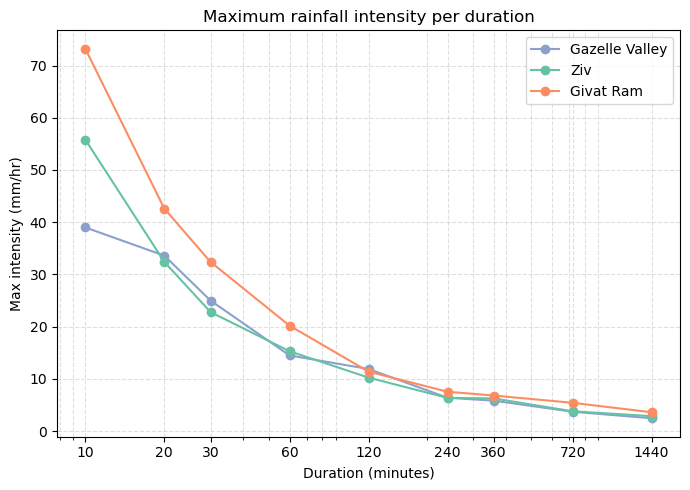

In [9]:
intens_cols = [c for c in ram_rain.columns if c.startswith('rain_intens_')]
durations   = sorted(int(c.replace('rain_intens_','').replace('min_mm_hr','')) for c in intens_cols)

fig, ax = plt.subplots(figsize=(7, 5))
for df, label, color in zip(rain_dfs, labels,
                            [s['color'] for s in cfg.STATIONS.values()]):
    maxvals = [df[f'rain_intens_{d}min_mm_hr'].max() for d in durations
               if f'rain_intens_{d}min_mm_hr' in df.columns]
    ax.plot(durations[:len(maxvals)], maxvals, marker='o', linewidth=1.5,
            color=color, label=label)

ax.set_xscale('log')
ax.set_xticks(durations)
ax.set_xticklabels(durations)
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Max intensity (mm/hr)')
ax.set_title('Maximum rainfall intensity per duration')
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()